In [1]:
import sys
sys.path.append("../new_way/")

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

from api import vqvae_inference

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import io

import os
import glob
import json

from dataclasses import dataclass, field
from typing import Optional, Dict, Any
from pathlib import Path
from collections import Counter

from vqvae_a import VQVAE, Quantizer

In [3]:
def get_paths(base_path):
    base_path = os.path.abspath(base_path)
    
    # Find the _m_best.pt file
    model_path = glob.glob(os.path.join(base_path, "*_m_best.pt"))[0]
    
    # Extract mode and run_id from model filename (e.g., "vqvae_a0_1772615526_m_best.pt")
    model_filename = os.path.basename(model_path)
    run_id = model_filename.split("_m_best")[0].split("_")[-1]  # 1772615526
    mode   = model_filename.split("_m_best")[0].split("_")[1]   # a0

    # Find the config JSON file
    config_matches = glob.glob(os.path.join(base_path, "config_*.json"))
    with open(config_matches[0], "r") as f:
        hyperparameters = json.load(f)

    data_path    = os.path.join(base_path, "data_partitions", "test.csv")
    loss_path    = os.path.join(base_path, "losses", f"{mode}_{run_id}", f"losses_{mode}_{run_id}.txt")
    metrics_path = os.path.join(base_path, "misc", f"test_metrics_{mode}_{run_id}.txt")

    # Most recent test.pkl under results/
    pkl_matches  = glob.glob(os.path.join(base_path, "results", "*", "test.pkl"))
    indices_path = max(pkl_matches, key=os.path.getmtime)

    return model_path, data_path, indices_path, loss_path, metrics_path, hyperparameters

In [4]:
base_path = r"/export/usuarios01/icmora/deploymentVQVAE/deployment-VQVAE/trainings/cpd/a2/train03/"
model_path, data_path, indices_path, loss_path, metrics_path, hyperparameters = get_paths(base_path)

In [5]:
all_indices = pd.read_pickle(indices_path)
list_of_indices = np.concatenate(all_indices["indices"].values)

mode_to_mask = {"a0": 0, "a1": 1, "a2": 2}

model = VQVAE(
    num_features        = 250,
    embed_dim           = hyperparameters["embed_dim"],
    num_embed           = hyperparameters["num_embed"],
    num_layers          = hyperparameters["num_layers"],
    conv_dims           = hyperparameters["conv_dims"],
    conv_kernel_sizes   = hyperparameters["conv_kernel_sizes"],
    conv_strides        = hyperparameters["conv_strides"],
    deconv_dims         = hyperparameters["deconv_dims"],
    deconv_kernel_sizes = hyperparameters["deconv_kernel_sizes"],
    deconv_strides      = hyperparameters["deconv_strides"],
    p                   = hyperparameters["dropout"],
    decay               = hyperparameters["decay"],
    threshold           = hyperparameters["threshold"],
    mask_flag           = mode_to_mask[hyperparameters["mode"]]
)

model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

# Codebooks Statistics

In [6]:
def calculate_codebook_stats(indices_obtained: list, number_original_indices: int):
    
    total = number_original_indices
    counts = Counter(indices_obtained)
    eps = 1e-10

    # Usage pctg

    used_codes = len(counts)
    usage_pctg = (used_codes/total) * 100

    # Perplexity

    p_i = np.array([counts.get(i, 0) for i in range(number_original_indices)]) / len(indices_obtained)

    shannon_entropy = - np.sum(p_i * np.log(p_i + eps), 0)
    perplexity = np.exp(shannon_entropy)

    # Collapse

    collapse_warn = usage_pctg < 10.0

    print(
        f'\n{"#" * 40}\n'
        f'        CODEBOOK STATISTICS\n'
        f'{"#" * 40}\n'
        f' Total Indices   : {total}\n'
        f' Used Indices    : {used_codes}\n'
        f' Usage           : {usage_pctg:.2f}%\n'
        f' Perplexity      : {perplexity:.2f} / {number_original_indices}\n'
        f' CB Collapse     : {collapse_warn}\n' 
        f'{"#" * 40}\n'
    )


    # Plots

    counts = Counter(list_of_indices)

    x_plot = np.arange(0, number_original_indices)
    y_plot = np.array([counts.get(i, 0) for i in x_plot])

    plt.figure(figsize=(12, 4))
    plt.bar(x_plot, y_plot, width=1.0)
    plt.xlabel("Code index")
    plt.ylabel("Count")
    plt.title("Codebook Usage Distribution")
    plt.show()

    p = y_plot / y_plot.sum()

    plt.figure(figsize=(12, 4))
    plt.bar(x_plot, p, width=1.0)
    plt.hlines(y = 1 / number_original_indices, xmin = x_plot[0], xmax = x_plot[-1], color = "red" ,linestyles= "--")
    plt.yscale("log")
    plt.xlabel("Code index")
    plt.ylabel("Probability")
    plt.title("Codebook Usage")
    plt.show()




########################################
        CODEBOOK STATISTICS
########################################
 Total Indices   : 512
 Used Indices    : 512
 Usage           : 100.00%
 Perplexity      : 200.72 / 512
 CB Collapse     : False
########################################



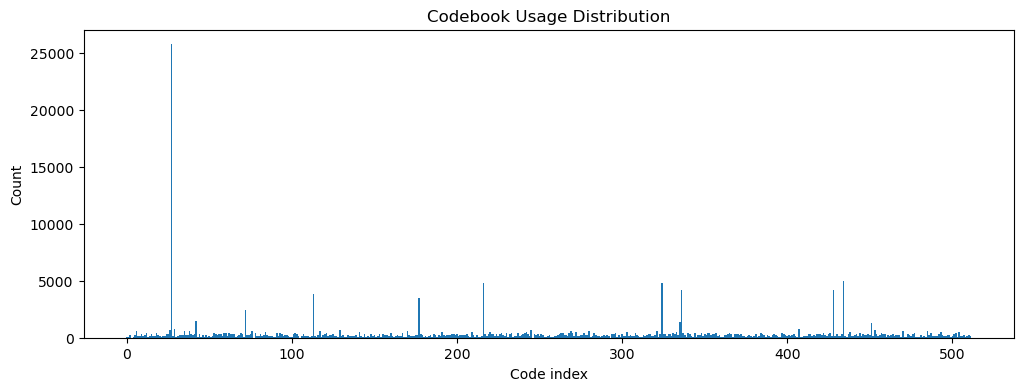

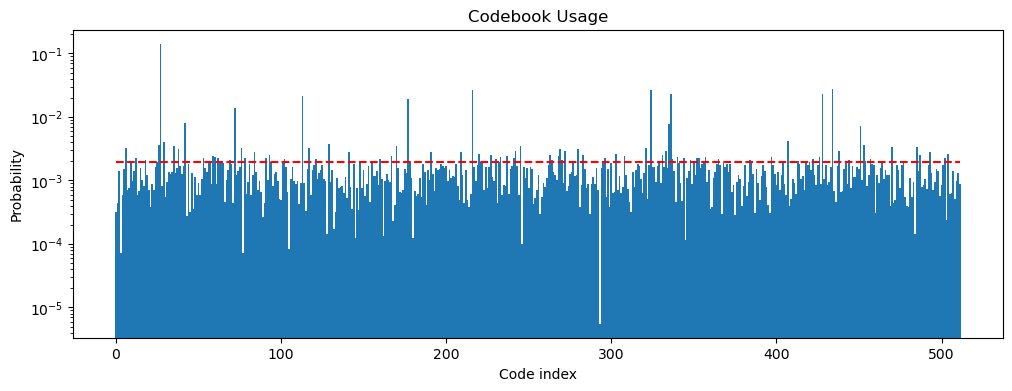

In [7]:
calculate_codebook_stats(list_of_indices, 512)

# Training Curves

In [8]:
def parse_training_log(filepath):

    data = []
    
    # Regex patterns to match log lines
    epoch_pattern = re.compile(r'Epoch (\d+)/\d+')
    train_pattern = re.compile(r'\[train\]\s+<loss>\s+reco:\s+([\d.]+)\s*\|\s*latent:\s+([\d.]+)\s*\|\s*overall:\s+([\d.]+)')
    val_pattern = re.compile(r'\[val\]\s+<loss>\s+reco:\s+([\d.]+)\s*\|\s*latent:\s+([\d.]+)\s*\|\s*overall:\s+([\d.]+)')
    
    with open(filepath, 'r', encoding='utf-8') as f:
        current_epoch = None
        train_losses = {}
        val_losses = {}
        
        for line in f:
            line = line.strip()
            
            epoch_match = epoch_pattern.match(line)
            if epoch_match:
                if current_epoch and train_losses and val_losses:
                    data.append({
                        'epoch': current_epoch,
                        'train_reco': train_losses['reco'],
                        'train_latent': train_losses['latent'],
                        'train_overall': train_losses['overall'],
                        'val_reco': val_losses['reco'],
                        'val_latent': val_losses['latent'],
                        'val_overall': val_losses['overall']
                    })
                current_epoch = int(epoch_match.group(1))
                train_losses = {}
                val_losses = {}
                continue
            
            train_match = train_pattern.search(line)
            if train_match:
                train_losses = {
                    'reco': float(train_match.group(1)),
                    'latent': float(train_match.group(2)),
                    'overall': float(train_match.group(3))
                }
                continue
            
            val_match = val_pattern.search(line)
            if val_match:
                val_losses = {
                    'reco': float(val_match.group(1)),
                    'latent': float(val_match.group(2)),
                    'overall': float(val_match.group(3))
                }
                continue
        
        if current_epoch and train_losses and val_losses:
            data.append({
                'epoch': current_epoch,
                'train_reco': train_losses['reco'],
                'train_latent': train_losses['latent'],
                'train_overall': train_losses['overall'],
                'val_reco': val_losses['reco'],
                'val_latent': val_losses['latent'],
                'val_overall': val_losses['overall']
            })
    
    return pd.DataFrame(data)


def plot_loss_curves(df, figsize=(12, 5)):
    """
    Plot training and validation loss curves.
    
    Args:
        df: DataFrame with parsed loss data
        save_path: Optional path to save the figure
        figsize: Figure size tuple
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle('VQ-VAE Training Loss Curves', fontsize=16, fontweight='bold')
    
    # Plot overall loss
    axes[0].plot(df['epoch'], df['train_overall'], label='Train', color='blue', linewidth=2)
    axes[0].plot(df['epoch'], df['val_overall'], label='Validation', color='red', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Overall Loss')
    axes[0].set_title('Overall Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 5.0)

    # Plot reconstruction loss
    axes[1].plot(df['epoch'], df['train_reco'], label='Train', color='blue', linewidth=2)
    axes[1].plot(df['epoch'], df['val_reco'], label='Validation', color='red', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Reconstruction Loss')
    axes[1].set_title('Reconstruction Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 5.0)

    # Plot latent loss
    axes[2].plot(df['epoch'], df['train_latent'], label='Train', color='blue', linewidth=2)
    axes[2].plot(df['epoch'], df['val_latent'], label='Validation', color='red', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Latent Loss')
    axes[2].set_title('Latent Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(0, 1.0)
    
    plt.tight_layout()
    
    plt.show()

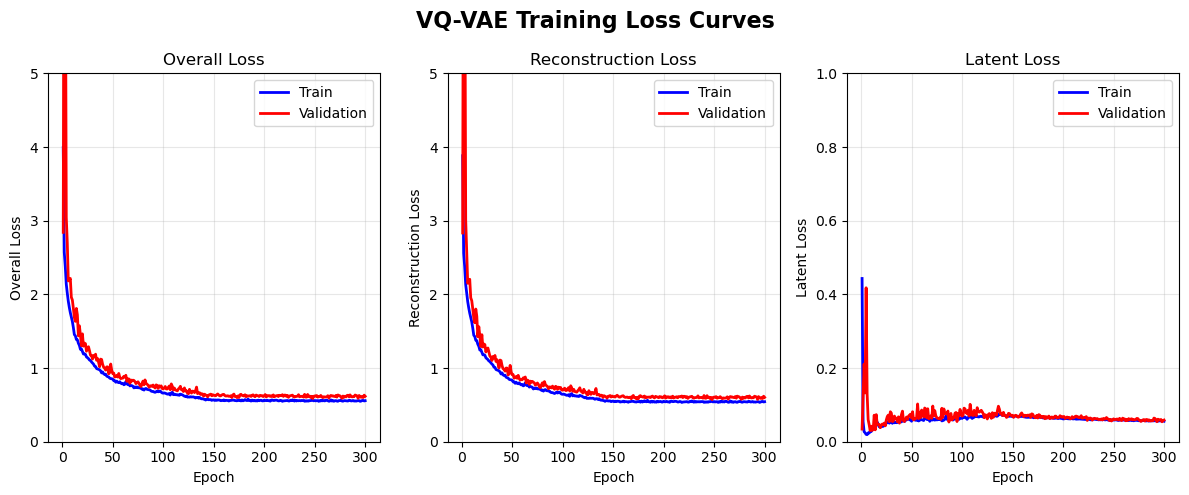

   Best validation epoch: 248
   Val Overall Loss: 0.5861
   Val Reco Loss: 0.5721
   Val Latent Loss: 0.0563


In [9]:
df_loss = parse_training_log(loss_path)

plot_loss_curves(df_loss)

best_idx = df_loss['val_overall'].idxmin()
print(f"   Best validation epoch: {df_loss.loc[best_idx, 'epoch']}")
print(f"   Val Overall Loss: {df_loss.loc[best_idx, 'val_overall']:.4f}")
print(f"   Val Reco Loss: {df_loss.loc[best_idx, 'val_reco']:.4f}")
print(f"   Val Latent Loss: {df_loss.loc[best_idx, 'val_latent']:.4f}")

# Comparsion with Original Models

In [10]:
def create_metrics_column(txt_content: str, csv_content: str) -> pd.DataFrame:
    """
    Parses the text file to extract MAE and F1 metrics, 
    and adds them as a new column to the provided CSV data.
    """
    metrics = {}
    current_var = None
    parsing_metrics = False
    
    # 1. Parse the text data
    for line in txt_content.split('\n'):
        line_s = line.strip()
        
        # Start parsing when we hit the "Test Metrics:" section
        if line_s == "Test Metrics:":
            parsing_metrics = True
            continue
            
        if parsing_metrics:
            # Check for a variable header (e.g., "Variable Sleep Start:")
            if line_s.startswith('Variable ') and line_s.endswith(':'):
                current_var = line_s.replace('Variable ', '').replace(':', '').strip()
                if current_var not in metrics:
                    metrics[current_var] = {}
            # Parse the actual metrics (e.g., "mae_xo: 1176.6090")
            elif current_var and ':' in line_s:
                key, val = line_s.split(':')
                metrics[current_var][key.strip()] = float(val.strip())

    # 2. Map CSV variables to text file variables
    var_map = {
        'Sleep Start (s)': 'Sleep Start',
        'Distance (m)': 'Location Distance',
        'Time at Home (m)': 'Location Time Home',
        'Sleep Duration (s)': 'Sleep Duration',
        'Time Walking (s)': 'Activity Walking',
        'App Usage (s)': 'App Usage Total',
        'Location Clusters': 'Location Clusters Count',
        'Total Steps': 'Steps Steps Total',
        'Weekend': 'Weekend',
        'Practiced Sport': 'Practiced Sport'
    }
    
    # 3. Read the CSV string into a DataFrame
    df = pd.read_csv(io.StringIO(csv_content))
    new_col = []
    
    # 4. Generate the new column based on variable names and type
    for _, row in df.iterrows():
        csv_var = row['Variable']
        csv_type = row['Type']
        
        txt_var = var_map.get(csv_var)
        
        # Determine the metric to extract (F1 for classifications, MAE for continuous)
        metric_prefix = 'f1' if txt_var in ['Weekend', 'Practiced Sport'] else 'mae'
        
        # Map MCAR -> xsm, XO -> xo
        type_suffix = 'xsm' if csv_type == 'MCAR' else 'xo'
        
        metric_key = f"{metric_prefix}_{type_suffix}"
        
        # Fetch the value
        val = metrics.get(txt_var, {}).get(metric_key, None)
        new_col.append(val)
        
    # Append to dataframe and return
    df['New Model'] = new_col
    return df



In [11]:
txt_data = open(metrics_path).read()
csv_data = """Variable,Type,A0,A1,A2
Sleep Start (s),XO,1315.63,1242.66,1177.78
Sleep Start (s),MCAR,5777.24,5651.99,5578.96
Distance (m),XO,12202.43,11627.66,12874.13
Distance (m),MCAR,17008.33,16681.98,15190.03
Time at Home (m),XO,146.17,143.58,174.94
Time at Home (m),MCAR,289.52,290.18,291.85
Sleep Duration (s),XO,4149.4,4055.13,5005.76
Sleep Duration (s),MCAR,6563.44,6615.74,6738.0
Time Walking (s),XO,1341.44,1298.03,1279.72
Time Walking (s),MCAR,1779.98,1742.47,1734.54
App Usage (s),XO,3784.17,3714.48,3968.0
App Usage (s),MCAR,5045.95,4973.86,4946.72
Location Clusters,XO,1.0887,1.0746,1.2469
Location Clusters,MCAR,1.3234,1.3143,1.398
Total Steps,XO,2101.48,3714.48,3968.0
Total Steps,MCAR,3056.67,3002.53,2993.74
Weekend,XO,0.995,0.996,0.9967
Practiced Sport,XO,0.9932,0.9941,0.9929
"""
updated_df = create_metrics_column(txt_data, csv_data)
print(updated_df)

              Variable  Type          A0          A1          A2   New Model
0      Sleep Start (s)    XO   1315.6300   1242.6600   1177.7800    966.4411
1      Sleep Start (s)  MCAR   5777.2400   5651.9900   5578.9600   4529.2514
2         Distance (m)    XO  12202.4300  11627.6600  12874.1300  14875.7532
3         Distance (m)  MCAR  17008.3300  16681.9800  15190.0300  14457.0632
4     Time at Home (m)    XO    146.1700    143.5800    174.9400    131.5270
5     Time at Home (m)  MCAR    289.5200    290.1800    291.8500    140.5621
6   Sleep Duration (s)    XO   4149.4000   4055.1300   5005.7600   5485.3164
7   Sleep Duration (s)  MCAR   6563.4400   6615.7400   6738.0000   5455.1113
8     Time Walking (s)    XO   1341.4400   1298.0300   1279.7200   1738.2954
9     Time Walking (s)  MCAR   1779.9800   1742.4700   1734.5400   1816.5584
10       App Usage (s)    XO   3784.1700   3714.4800   3968.0000   5753.8957
11       App Usage (s)  MCAR   5045.9500   4973.8600   4946.7200   6045.6998

In [12]:
def plot_reconstructions(df):

    df_melted = df.melt(id_vars=['Variable', 'Type'], var_name='Model', value_name='Value')

    f1_vars = ['Weekend', 'Practiced Sport']
    df_f1 = df_melted[df_melted['Variable'].isin(f1_vars)].copy()
    df_error = df_melted[~df_melted['Variable'].isin(f1_vars)].copy()

    sns.set_theme(style="whitegrid")

    highlight_palette = {
        'A0': 'silver',
        'A1': 'silver',
        'A2': 'silver',
        'New Model': '#FF5733' 
    }
    model_order = ['A0', 'A1', 'A2', 'New Model']

    g = sns.catplot(
        data=df_error, x='Type', y='Value', hue='Model', col='Variable',
        kind='bar', col_wrap=3, height=3, aspect=1.2, sharey=False,
        palette=highlight_palette, hue_order=model_order
    )
    g.figure.suptitle('Error Metrics Comparison', y=1.02, fontsize=16)
    g.set_titles("{col_name}")
    g.set_axis_labels("", "Error Value")


    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df_f1, x='Variable', y='Value', hue='Model',
        palette=highlight_palette, hue_order=model_order
    )
    plt.title('F1 Score Comparison')
    plt.ylabel('F1 Score')
    plt.ylim(0.5, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


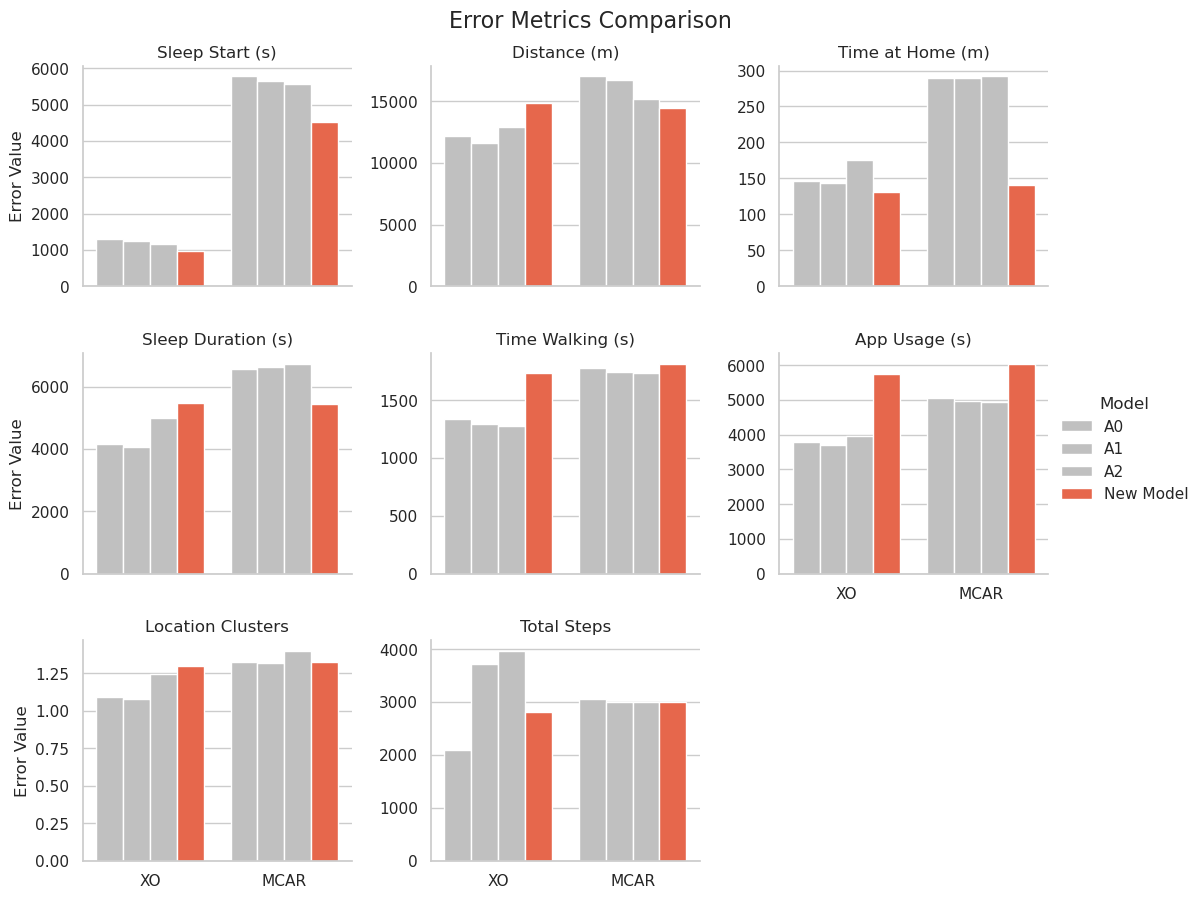

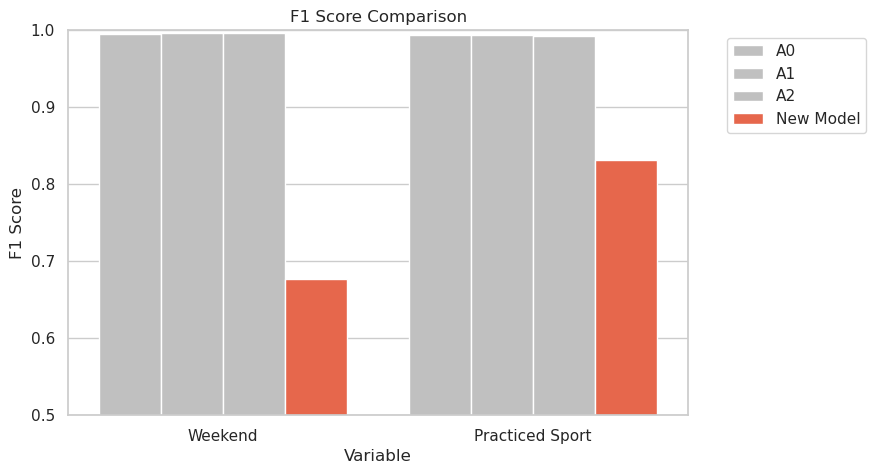

In [13]:
plot_reconstructions(updated_df)